# 🧠 Multimodal Image Registration Tutorial

**Run on Google Colab with T4 GPU** — *Runtime → Change runtime type → T4 GPU*

---

## What is Image Registration?

Image registration spatially aligns two or more images of the same scene taken at different times, viewpoints, or with different sensors. In **multimodal** registration the images come from **different imaging modalities** (e.g., MRI + CT, PET + MRI), which means pixel intensities represent different physical quantities.

### 🗺️ Tutorial Roadmap

| Section | Method | Library |
|---------|--------|---------|
| 1 | Setup & Synthetic Data Generation | NumPy / SciPy |
| 2 | Rigid Registration (Translation + Rotation) | SimpleITK |
| 3 | Affine Registration | SimpleITK |
| 4 | Deformable B-Spline Registration | SimpleITK |
| 5 | Deep Learning Registration (VoxelMorph-style) | PyTorch |
| 6 | Evaluation Metrics (NCC, MI, SSIM, Jacobian) | Custom |
| 7 | Full Comparison & 3D Extension | All |
| Bonus | Real NIfTI Data with ANTsPy | ANTsPy |

### 🔑 Key Concepts
- **Fixed image** — the reference/target image  
- **Moving image** — the image to be aligned to the fixed image  
- **Similarity metric** — measures alignment quality (NCC, MI, MSE)  
- **Transformation** — the spatial mapping (rigid, affine, deformable)  
- **Optimizer** — updates transform parameters to maximize similarity

---

## Section 1 — Environment Setup & Synthetic Data Generation

In [84]:
# Install dependencies
!pip install SimpleITK -q
!pip install antspyx -q
!pip install nibabel scikit-image -q
print("✅ All packages installed")

✅ All packages installed


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.ndimage as ndi
from scipy.ndimage import gaussian_filter, map_coordinates, affine_transform
from skimage.draw import disk, ellipse
from skimage.metrics import normalized_mutual_information, structural_similarity as ssim
import SimpleITK as sitk
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
import warnings, time
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if device.type == 'cuda':
    print(f"   GPU  : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

np.random.seed(42); torch.manual_seed(42)
print("✅ Environment ready!")

🖥️  Device: cuda
   GPU  : Tesla T4
   VRAM : 15.6 GB
✅ Environment ready!


In [86]:
# ── Synthetic Multimodal Brain Phantom ───────────────────────────────────────
def create_brain_phantom(size=256, modality='mri'):
    img = np.zeros((size, size), dtype=np.float32)
    cx = cy = size // 2
    # Skull
    rr, cc = ellipse(cx, cy, int(size*.46), int(size*.42))
    img[rr, cc] = 0.30 if modality == 'mri' else 0.90
    # Gray matter
    rr, cc = ellipse(cx, cy, int(size*.40), int(size*.36))
    img[rr, cc] = 0.60 if modality == 'mri' else 0.40
    # White matter
    rr, cc = ellipse(cx, cy, int(size*.28), int(size*.24))
    img[rr, cc] = 0.90 if modality == 'mri' else 0.20
    # Ventricles (CSF)
    for dx in [-size//16, size//16]:
        rr, cc = ellipse(cx+dx, cy, int(size*.08), int(size*.04))
        img[rr, cc] = 0.05 if modality == 'mri' else 0.25
    # Basal ganglia
    for dx, dy in [(-size//10,-size//10),(size//10,-size//10),
                   (-size//12, size//12),(size//12, size//12)]:
        rr, cc = disk((cx+dx, cy+dy), size//20)
        img[rr, cc] = 0.75 if modality == 'mri' else 0.35
    img = gaussian_filter(img, sigma=2.5)
    noise = 0.02 if modality == 'mri' else 0.015
    img += np.random.normal(0, noise, img.shape)
    return np.clip(img, 0, 1)

def apply_rigid_transform(image, angle_deg=15.0, tx=22, ty=-18):
    h, w = image.shape; cx = cy = h/2
    a = np.deg2rad(angle_deg)
    R = np.array([[np.cos(a), -np.sin(a)],
                  [np.sin(a),  np.cos(a)]])
    offset = np.array([cx, cy]) - R @ np.array([cx+tx, cy+ty])
    out = affine_transform(image, R, offset=offset, order=3, mode='constant', cval=0)
    return out, {'angle_deg': angle_deg, 'tx': tx, 'ty': ty}

SIZE = 256
fixed_mri     = create_brain_phantom(SIZE, 'mri')
moving_ct_raw = create_brain_phantom(SIZE, 'ct')
moving_ct, gt = apply_rigid_transform(moving_ct_raw)

print("📐 Image shape:", fixed_mri.shape)
print("🔄 Ground-truth transform:", gt)

📐 Image shape: (256, 256)
🔄 Ground-truth transform: {'angle_deg': 15.0, 'tx': 22, 'ty': -18}


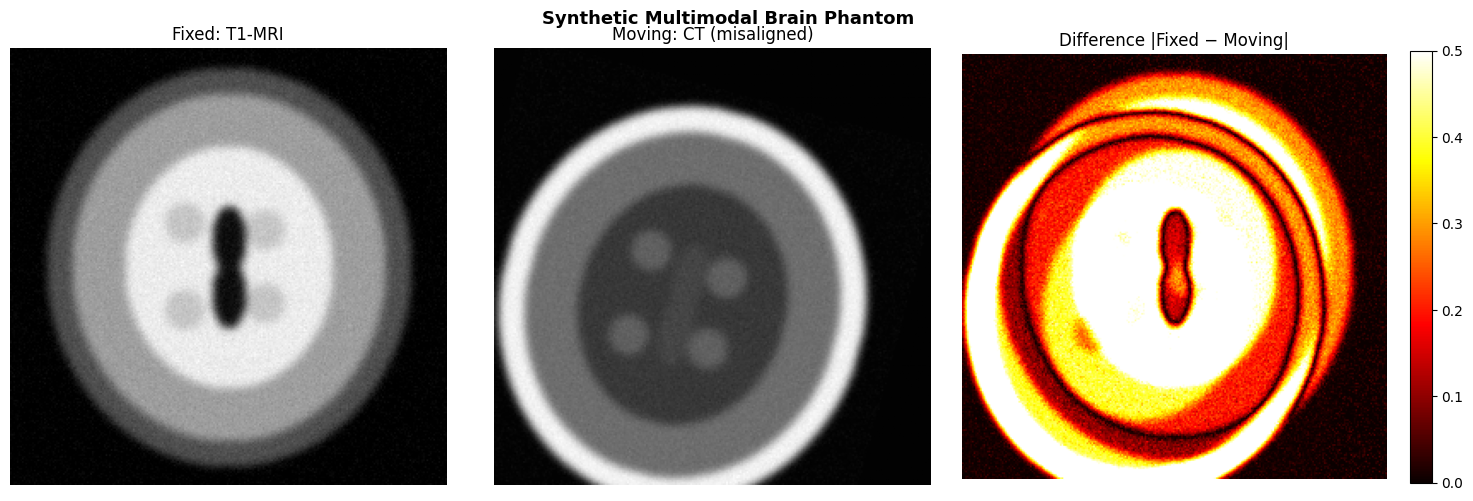

Initial MAD=0.2794  NMI=1.0769


In [87]:
# ── Initial visualisation ────────────────────────────────────────────────────
def show_registration(fixed, moving, registered,
                      suptitle='Registration Result'):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.01)
    for ax, img, title in zip(
            axes,
            [fixed, moving, registered, None],
            ['Fixed (MRI)', 'Moving (CT)', 'Registered', 'Checkerboard Overlay']):
        if img is not None:
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        else:
            h, w = fixed.shape; blk = 32
            checker = np.zeros((h,w))
            for i in range(0,h,blk*2):
                for j in range(0,w,blk*2):
                    checker[i:i+blk, j:j+blk] = 1
                    checker[i+blk:i+2*blk, j+blk:j+2*blk] = 1
            ax.imshow(np.where(checker, fixed, registered), cmap='gray', vmin=0, vmax=1)
        ax.set_title(title, fontsize=10); ax.axis('off')
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Synthetic Multimodal Brain Phantom', fontsize=13, fontweight='bold')
axes[0].imshow(fixed_mri,  cmap='gray'); axes[0].set_title('Fixed: T1-MRI');        axes[0].axis('off')
axes[1].imshow(moving_ct,  cmap='gray'); axes[1].set_title('Moving: CT (misaligned)');axes[1].axis('off')
diff = np.abs(fixed_mri - moving_ct)
im = axes[2].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
axes[2].set_title('Difference |Fixed − Moving|'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

nmi_init = normalized_mutual_information(fixed_mri, moving_ct)
print(f"Initial MAD={diff.mean():.4f}  NMI={nmi_init:.4f}")

---
## Section 2 — Rigid Registration (SimpleITK)

Rigid registration recovers **rotation + translation** (3 DOF in 2D, 6 DOF in 3D).

For multimodal images we use **Mattes Mutual Information** as the similarity metric because it makes no assumptions about the intensity relationship between modalities.

```
Fixed Image ──┐
              ├─→ [Mattes MI] ─→ [Gradient Descent] ─→ [Euler2D Transform] ─→ Registered
Moving Image ─┘
```

In [88]:
def numpy_to_sitk(arr):
    return sitk.GetImageFromArray(arr.astype(np.float32))

def sitk_to_numpy(img):
    return sitk.GetArrayFromImage(img).astype(np.float32)

def resample(fixed_s, moving_s, transform, interp=sitk.sitkLinear):
    r = sitk.ResampleImageFilter()
    r.SetReferenceImage(fixed_s); r.SetInterpolator(interp)
    r.SetDefaultPixelValue(0);    r.SetTransform(transform)
    return r.Execute(moving_s)

fixed_s  = numpy_to_sitk(fixed_mri)
moving_s = numpy_to_sitk(moving_ct)

def rigid_registration(fixed_s, moving_s):
    metric_vals = []
    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.20) #every iteration uses only 20% of pixels to estimate MI, so has variance
    reg.SetInterpolator(sitk.sitkLinear)
    reg.SetOptimizerAsGradientDescent(
        learningRate=1.0, numberOfIterations=200,
        convergenceMinimumValue=1e-6, convergenceWindowSize=10)
    reg.SetOptimizerScalesFromPhysicalShift()
    reg.SetShrinkFactorsPerLevel([4, 2, 1])
    reg.SetSmoothingSigmasPerLevel([2, 1, 0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
    init = sitk.CenteredTransformInitializer(
        fixed_s, moving_s, sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY)
    reg.SetInitialTransform(init, inPlace=True)
    def cb(): metric_vals.append(reg.GetMetricValue())
    reg.AddCommand(sitk.sitkIterationEvent, cb)
    t0 = time.time()
    tf = reg.Execute(fixed_s, moving_s)
    print(f"✅ Rigid done in {time.time()-t0:.1f}s | metric={reg.GetMetricValue():.5f}")
    euler = sitk.Euler2DTransform(init)
    print(f"   Recovered angle : {np.rad2deg(euler.GetAngle()):.2f}°  (GT: {gt['angle_deg']}°)")
    print(f"   Recovered transl: {tuple(round(v,1) for v in euler.GetTranslation())}  "
          f"(GT: ({gt['tx']}, {gt['ty']}))")
    return sitk_to_numpy(resample(fixed_s, moving_s, tf)), tf, metric_vals

print("🔄 Running Rigid Registration...")
rigid_result, rigid_tf, rigid_metrics = rigid_registration(fixed_s, moving_s)

🔄 Running Rigid Registration...
✅ Rigid done in 0.1s | metric=-1.14037
   Recovered angle : -2.36°  (GT: 15.0°)
   Recovered transl: (-13.8, 20.4)  (GT: (22, -18))


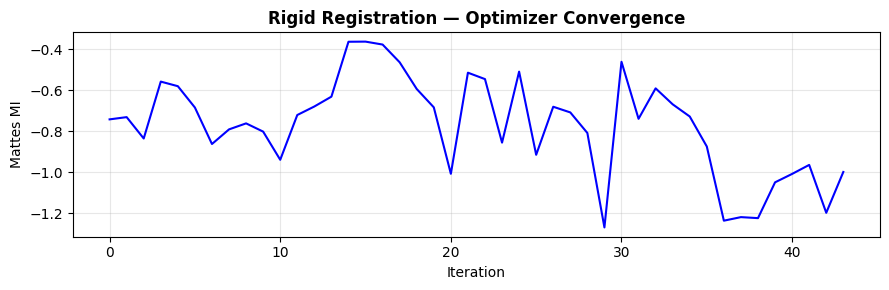

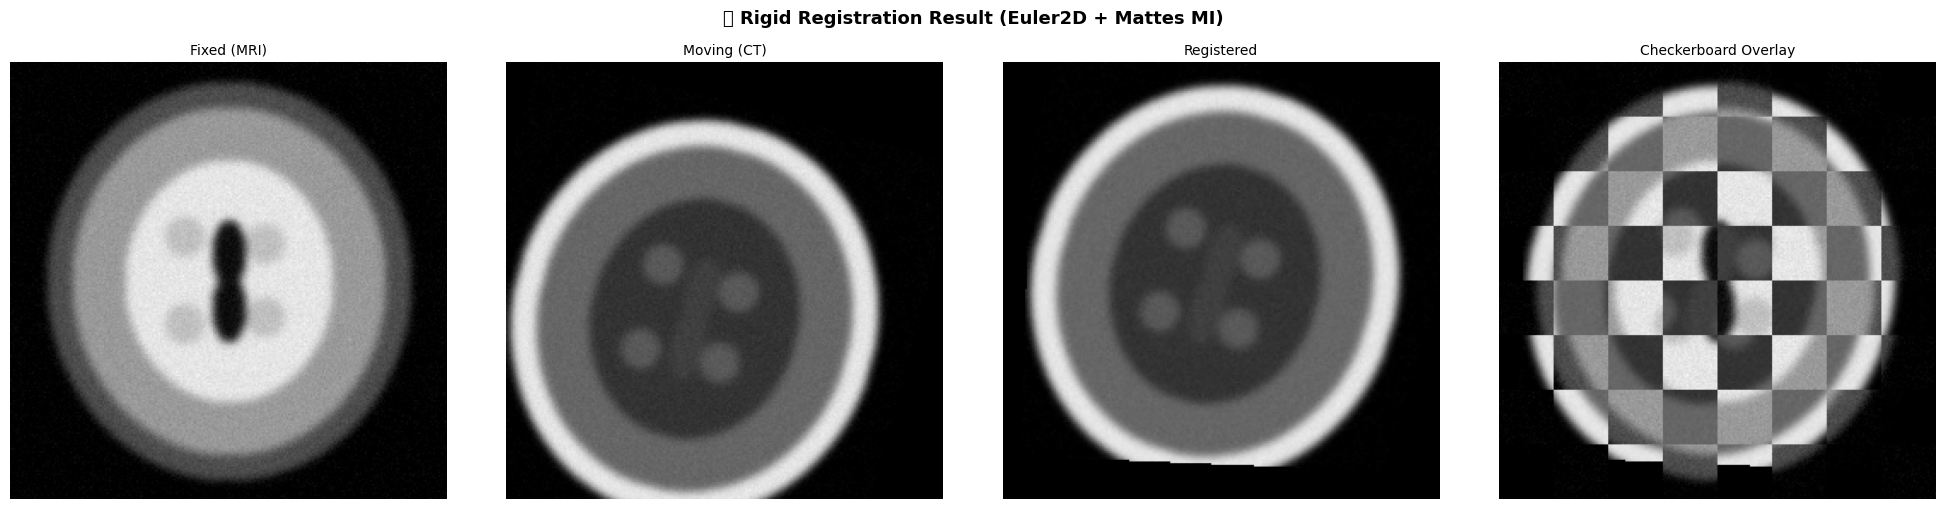

NMI: 1.0769 → 1.1937  (+0.1167)


In [89]:
# Convergence curve
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(rigid_metrics, 'b-', linewidth=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('Mattes MI'); ax.grid(alpha=.3)
ax.set_title('Rigid Registration — Optimizer Convergence', fontweight='bold')
plt.tight_layout(); plt.show()

show_registration(fixed_mri, moving_ct, rigid_result,
                  suptitle='🔒 Rigid Registration Result (Euler2D + Mattes MI)')
nmi_rigid = normalized_mutual_information(fixed_mri, rigid_result)
print(f"NMI: {nmi_init:.4f} → {nmi_rigid:.4f}  (+{nmi_rigid-nmi_init:.4f})")

Good alignment  →  edges are continuous across boundaries

Bad alignment   →  edges jump or shift at boundaries  

---
## Section 3 — Affine Registration

Affine registration adds **scaling** and **shearing** to the rigid transform:

$$\mathbf{x}' = A\mathbf{x} + \mathbf{t}$$

- 2D: 6 DOF (rotation, 2 translations, 2 scales, 1 shear)  
- 3D: 12 DOF  

We **warm-start** from the rigid result to avoid local minima.

🔄 Running Affine Registration (warm-started from rigid)...
✅ Affine done in 29.1s | metric=-1.56108 | iters=490


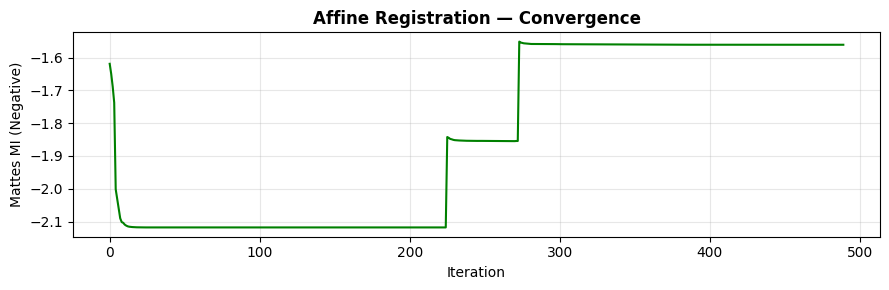

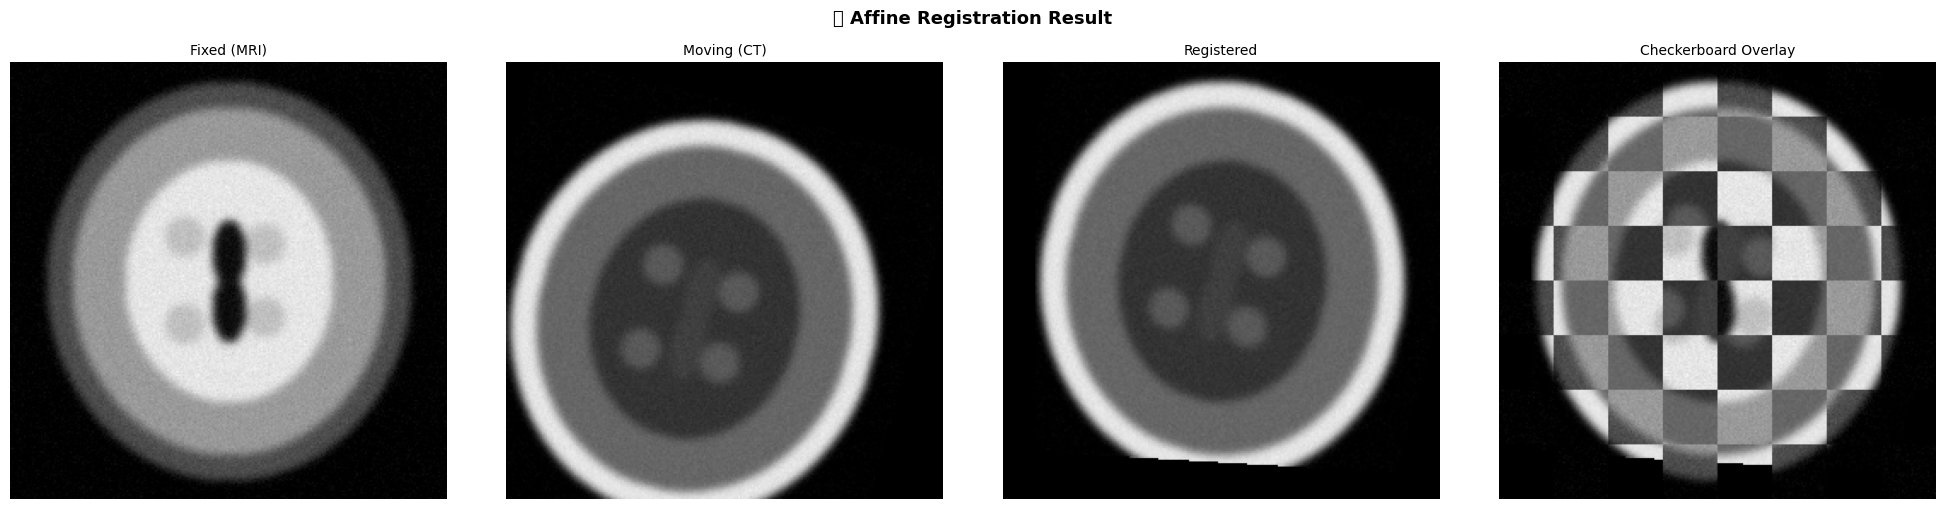

NMI: Rigid=1.1937  Affine=1.2562


In [90]:
def affine_registration(fixed_s, moving_s, init_tf=None):
    metric_vals = []
    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=64)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.25)
    reg.SetInterpolator(sitk.sitkBSpline)
    reg.SetOptimizerAsGradientDescentLineSearch(
        learningRate=0.5, numberOfIterations=300,
        convergenceMinimumValue=1e-7, convergenceWindowSize=15)
    reg.SetOptimizerScalesFromPhysicalShift()
    reg.SetShrinkFactorsPerLevel([4, 2, 1])
    reg.SetSmoothingSigmasPerLevel([3, 1, 0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    if init_tf is not None:
        # Properly initialize the affine transform and optimize in place
        e = sitk.Euler2DTransform(init_tf)
        aff = sitk.AffineTransform(2)
        aff.SetMatrix(e.GetMatrix())
        aff.SetTranslation(e.GetTranslation())
        aff.SetCenter(e.GetCenter())
        reg.SetInitialTransform(aff, inPlace=True)
    else:
        aff = sitk.CenteredTransformInitializer(
            fixed_s, moving_s, sitk.AffineTransform(2),
            sitk.CenteredTransformInitializerFilter.GEOMETRY)
        reg.SetInitialTransform(aff, inPlace=True)

    reg.AddCommand(sitk.sitkIterationEvent, lambda: metric_vals.append(reg.GetMetricValue()))
    t0 = time.time()
    tf = reg.Execute(fixed_s, moving_s)
    print(f"✅ Affine done in {time.time()-t0:.1f}s | metric={reg.GetMetricValue():.5f} | iters={len(metric_vals)}")
    return sitk_to_numpy(resample(fixed_s, moving_s, tf, sitk.sitkBSpline)), tf, metric_vals

print("🔄 Running Affine Registration (warm-started from rigid)...")
affine_result, affine_tf, affine_metrics = affine_registration(fixed_s, moving_s, rigid_tf)

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(affine_metrics,'g-',linewidth=1.5); ax.set_xlabel('Iteration')
ax.set_ylabel('Mattes MI (Negative)'); ax.grid(alpha=.3)
ax.set_title('Affine Registration — Convergence',fontweight='bold')
plt.tight_layout(); plt.show()

show_registration(fixed_mri, moving_ct, affine_result, suptitle='📐 Affine Registration Result')
nmi_affine = normalized_mutual_information(fixed_mri, affine_result)
print(f"NMI: Rigid={nmi_rigid:.4f}  Affine={nmi_affine:.4f}")

---
## Section 4 — Deformable B-Spline Registration

**B-Spline Free-Form Deformation (FFD)** adds a smooth non-rigid warp on top of the affine transform. Each voxel gets its own displacement, constrained by B-spline basis functions:

$$\mathbf{u}(\mathbf{x}) = \sum_{l,m} \phi_{l,m} \cdot B_l(u) \cdot B_m(v)$$

Control point grid spacing trades off **flexibility** vs. **regularity**.  
We use **L-BFGS-B** (quasi-Newton) which is much faster than gradient descent for high-DOF problems.

In [91]:
# Add elastic deformation to demo
def add_elastic_deform(image, strength=10.0, sigma=25.0, seed=7):
    np.random.seed(seed)
    h, w = image.shape
    dx = gaussian_filter(np.random.randn(h,w)*strength, sigma)
    dy = gaussian_filter(np.random.randn(h,w)*strength, sigma)
    x,y = np.meshgrid(np.arange(w), np.arange(h))
    coords = [np.clip(y+dy,0,h-1), np.clip(x+dx,0,w-1)]
    return map_coordinates(image, coords, order=3, mode='constant'), dx, dy

moving_ct_deform, true_dx, true_dy = add_elastic_deform(moving_ct)
moving_deform_s = numpy_to_sitk(moving_ct_deform.astype(np.float32))

def bspline_registration(fixed_s, moving_s, init_tf=None, mesh_size=[8,8]):
    metric_vals = []
    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=64)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.30)
    reg.SetInterpolator(sitk.sitkBSpline)
    reg.SetOptimizerAsLBFGSB(
        gradientConvergenceTolerance=1e-5, numberOfIterations=150,
        maximumNumberOfCorrections=5, maximumNumberOfFunctionEvaluations=2000,
        costFunctionConvergenceFactor=1e7)
    reg.SetShrinkFactorsPerLevel([2,1])
    reg.SetSmoothingSigmasPerLevel([2,0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    bs_init = sitk.BSplineTransformInitializer(
        image1=fixed_s, transformDomainMeshSize=mesh_size, order=3)
    if init_tf is not None:
        reg.SetMovingInitialTransform(init_tf)
        reg.SetInitialTransform(bs_init, inPlace=True)
    else:
        reg.SetInitialTransform(bs_init, inPlace=True)

    reg.AddCommand(sitk.sitkIterationEvent, lambda: metric_vals.append(reg.GetMetricValue()))
    t0 = time.time()
    tf_bs = reg.Execute(fixed_s, moving_s)

    if init_tf is not None:
        tf = sitk.CompositeTransform(2)
        tf.AddTransform(init_tf)
        tf.AddTransform(tf_bs)
    else:
        tf = tf_bs

    print(f"✅ B-Spline done in {time.time()-t0:.1f}s | metric={reg.GetMetricValue():.5f} | iters={len(metric_vals)}")
    return sitk_to_numpy(resample(fixed_s, moving_s, tf, sitk.sitkBSpline)), tf, metric_vals

print("🔄 Running B-Spline Deformable Registration...")
bspline_result, bspline_tf, bspline_metrics = bspline_registration(
    fixed_s, moving_deform_s, init_tf=affine_tf, mesh_size=[8,8])

🔄 Running B-Spline Deformable Registration...
✅ B-Spline done in 10.3s | metric=-1.66759 | iters=423


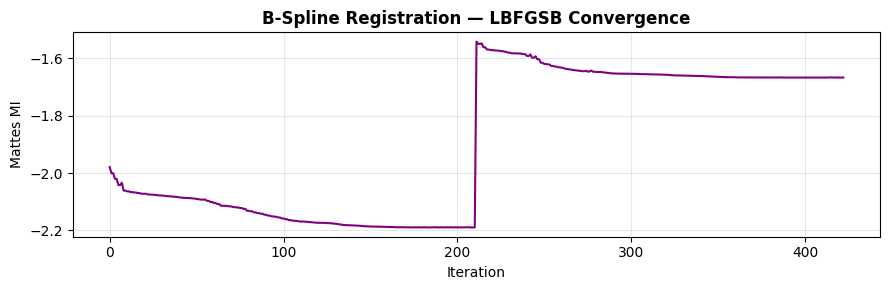

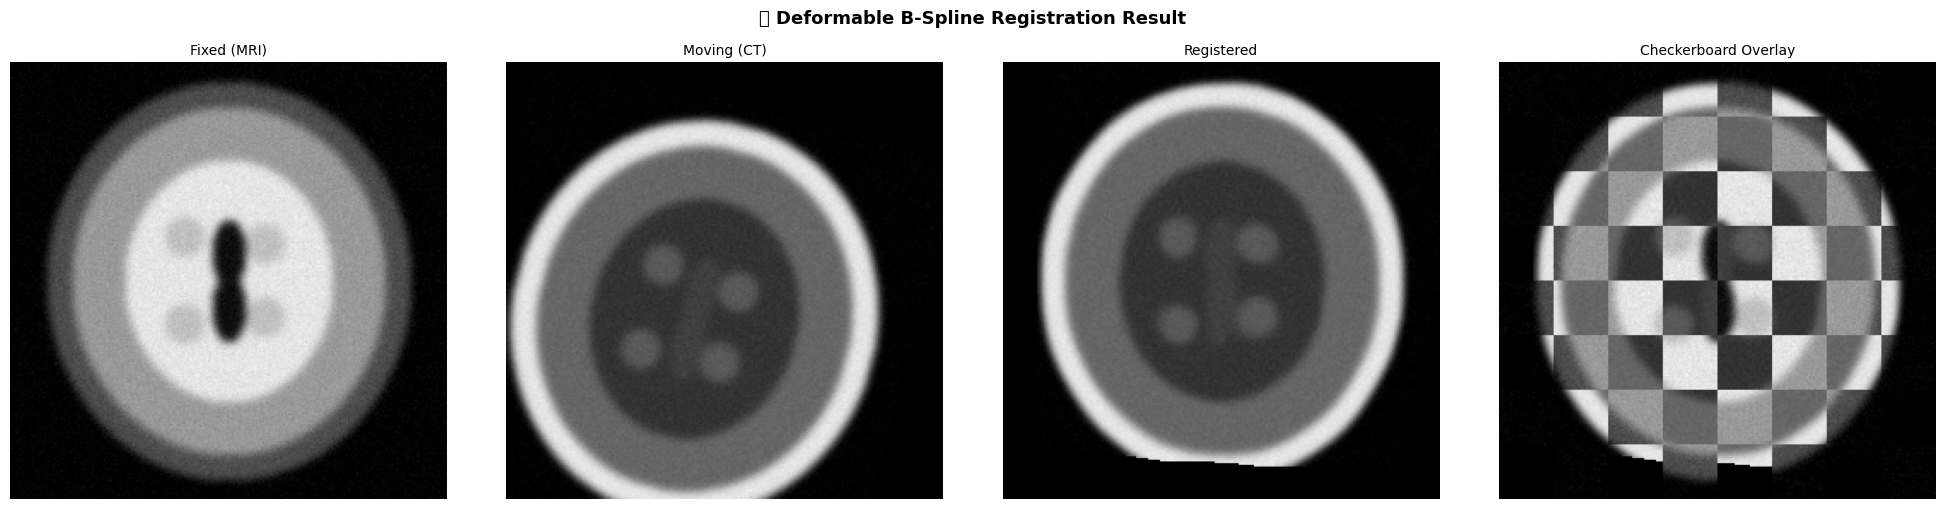

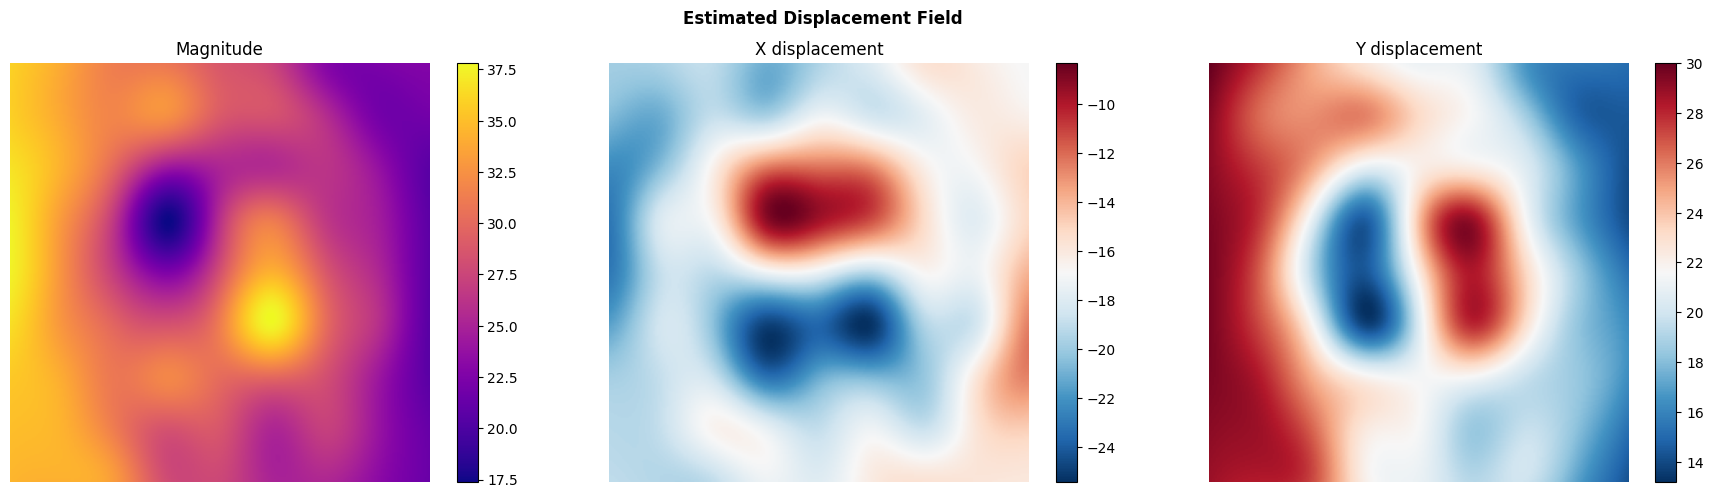

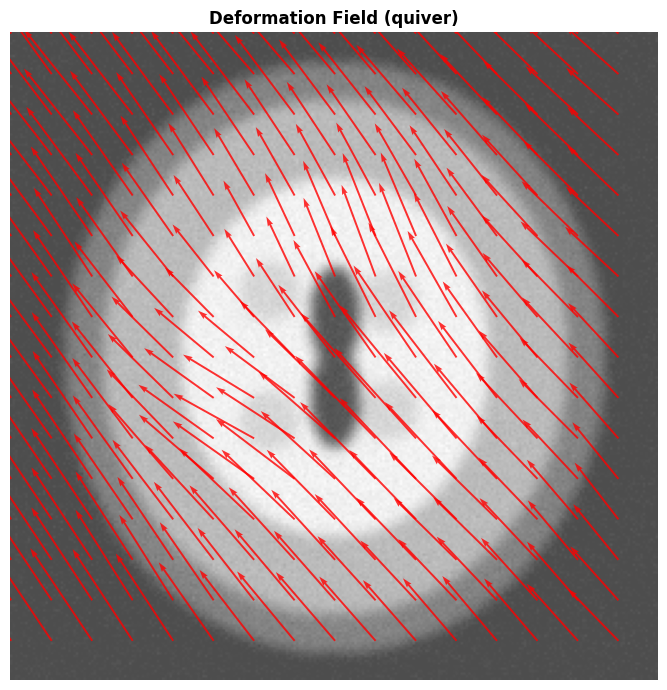

In [92]:
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(bspline_metrics,'purple',linewidth=1.5); ax.set_xlabel('Iteration')
ax.set_ylabel('Mattes MI'); ax.grid(alpha=.3)
ax.set_title('B-Spline Registration — LBFGSB Convergence',fontweight='bold')
plt.tight_layout(); plt.show()

show_registration(fixed_mri, moving_ct_deform, bspline_result,
                  suptitle='🌀 Deformable B-Spline Registration Result')

# Displacement field
disp_filter = sitk.TransformToDisplacementFieldFilter()
disp_filter.SetReferenceImage(fixed_s)
disp_sitk = disp_filter.Execute(bspline_tf)
disp = sitk.GetArrayFromImage(disp_sitk)

fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Estimated Displacement Field',fontsize=12,fontweight='bold')
mag = np.linalg.norm(disp, axis=2)
im0=axes[0].imshow(mag,cmap='plasma'); axes[0].set_title('Magnitude'); axes[0].axis('off'); plt.colorbar(im0,ax=axes[0],fraction=.046)
im1=axes[1].imshow(disp[:,:,0],cmap='RdBu_r'); axes[1].set_title('X displacement'); axes[1].axis('off'); plt.colorbar(im1,ax=axes[1],fraction=.046)
im2=axes[2].imshow(disp[:,:,1],cmap='RdBu_r'); axes[2].set_title('Y displacement'); axes[2].axis('off'); plt.colorbar(im2,ax=axes[2],fraction=.046)
plt.tight_layout(); plt.show()

# Quiver
fig,ax=plt.subplots(figsize=(7,7))
ax.imshow(fixed_mri,cmap='gray',alpha=.7)
step=16; h,w=fixed_mri.shape
Y,X=np.mgrid[0:h:step,0:w:step]
ax.quiver(X,Y,disp[::step,::step,0],disp[::step,::step,1],
          color='red',scale=200,width=.003,alpha=.8)
ax.set_title('Deformation Field (quiver)',fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.show()

---
## Section 5 — Deep Learning Registration (VoxelMorph-style)

**VoxelMorph** (Balakrishnan et al., IEEE TMI 2019) learns a U-Net that directly predicts a dense displacement field from a pair of images.

```
[Fixed | Moving] → U-Net (Encoder-Decoder) → Displacement φ → STN → Registered
```

**Loss:**  
$$\mathcal{L} = -\text{NCC}(I_f,\, I_m \circ \phi) \;+\; \lambda \|\nabla\phi\|^2$$

- NCC is preferred over MSE for multimodal images  
- The gradient regularizer keeps the field smooth and physically plausible

In [93]:
class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1), nn.LeakyReLU(.2,True),
            nn.Conv2d(oc,oc,3,padding=1), nn.LeakyReLU(.2,True))
    def forward(self,x): return self.b(x)

class VoxelMorph2D(nn.Module):
    def __init__(self, img_size=(256,256), F=[16,32,64,128]):
        super().__init__()
        self.img_size = img_size
        self.e1=ConvBlock(2,F[0]); self.e2=ConvBlock(F[0],F[1])
        self.e3=ConvBlock(F[1],F[2]); self.e4=ConvBlock(F[2],F[3])
        self.pool=nn.MaxPool2d(2)
        self.bn=ConvBlock(F[3],F[3])
        self.u4=nn.ConvTranspose2d(F[3],F[3],2,stride=2); self.d4=ConvBlock(F[3]*2,F[2])
        self.u3=nn.ConvTranspose2d(F[2],F[2],2,stride=2); self.d3=ConvBlock(F[2]*2,F[1])
        self.u2=nn.ConvTranspose2d(F[1],F[1],2,stride=2); self.d2=ConvBlock(F[1]*2,F[0])
        self.u1=nn.ConvTranspose2d(F[0],F[0],2,stride=2); self.d1=ConvBlock(F[0]*2,F[0])
        self.flow=nn.Conv2d(F[0],2,3,padding=1)
        nn.init.normal_(self.flow.weight,0,1e-5); nn.init.zeros_(self.flow.bias)

    def forward(self, x):
        e1=self.e1(x); e2=self.e2(self.pool(e1))
        e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bn(self.pool(e4))
        d4=self.d4(torch.cat([self.u4(b),e4],1))
        d3=self.d3(torch.cat([self.u3(d4),e3],1))
        d2=self.d2(torch.cat([self.u2(d3),e2],1))
        d1=self.d1(torch.cat([self.u1(d2),e1],1))
        flow=self.flow(d1)
        return self._warp(x[:,1:2],flow), flow

    def _warp(self, mov, flow):
        B,_,H,W=mov.shape
        gy,gx=torch.meshgrid(
            torch.linspace(-1,1,H,device=mov.device),
            torch.linspace(-1,1,W,device=mov.device), indexing='ij')
        grid=torch.stack([gx,gy],-1).unsqueeze(0).expand(B,-1,-1,-1)
        fn=flow.permute(0,2,3,1).clone()
        fn[...,0]/=(W/2); fn[...,1]/=(H/2)
        return F.grid_sample(mov,grid+fn,align_corners=True,
                             mode='bilinear',padding_mode='border')

def ncc_loss(f, m, win=9):
    p=win//2; k=torch.ones(1,1,win,win,device=f.device)/(win*win)
    fm=F.conv2d(f,k,padding=p); mm=F.conv2d(m,k,padding=p)
    fc=f-fm; mc=m-mm
    f2=F.conv2d(fc**2,k,padding=p); m2=F.conv2d(mc**2,k,padding=p)
    cc=F.conv2d(fc*mc,k,padding=p)
    return -(cc/(torch.sqrt(f2*m2+1e-8)+1e-8)).mean()

def smooth_loss(flow):
    dy=(flow[:,:,1:,:]-flow[:,:,:-1,:]).pow(2)
    dx=(flow[:,:,:,1:]-flow[:,:,:,:-1]).pow(2)
    return (dy.mean()+dx.mean())/2

model=VoxelMorph2D((SIZE,SIZE)).to(device)
print(f"🧠 VoxelMorph2D  params={sum(p.numel() for p in model.parameters() if p.requires_grad):,}  device={device}")

🧠 VoxelMorph2D  params=925,202  device=cuda


In [94]:
def to_tensor(arr): return torch.from_numpy(arr).float().unsqueeze(0).unsqueeze(0).to(device)

fixed_t  = to_tensor(fixed_mri)
moving_t = to_tensor(moving_ct)
inp      = torch.cat([fixed_t, moving_t], 1)

opt  = optim.Adam(model.parameters(), lr=1e-4)
sched= optim.lr_scheduler.StepLR(opt, step_size=150, gamma=0.5)
LAMBDA=2.0; N=400
hist={'total':[],'sim':[],'smooth':[]}

print(f"🔄 Training VoxelMorph for {N} epochs on {device}...")
t0=time.time()
model.train()
for epoch in range(N):
    opt.zero_grad()
    reg_t, flow = model(inp)
    sl = ncc_loss(fixed_t, reg_t)
    rl = smooth_loss(flow)
    loss= sl + LAMBDA*rl
    loss.backward(); opt.step(); sched.step()
    hist['total'].append(loss.item()); hist['sim'].append(sl.item()); hist['smooth'].append(rl.item())
    if (epoch+1)%100==0:
        print(f"  Epoch {epoch+1:4d} | total={loss.item():.4f}  ncc={sl.item():.4f}  smooth={rl.item():.4f}  t={time.time()-t0:.0f}s")
print(f"\n✅ Training complete in {time.time()-t0:.1f}s")

🔄 Training VoxelMorph for 400 epochs on cuda...
  Epoch  100 | total=-0.0142  ncc=-0.0156  smooth=0.0007  t=1s
  Epoch  200 | total=-0.0187  ncc=-0.0201  smooth=0.0007  t=2s
  Epoch  300 | total=-0.0247  ncc=-0.0285  smooth=0.0019  t=3s
  Epoch  400 | total=-0.0300  ncc=-0.0368  smooth=0.0034  t=4s

✅ Training complete in 4.4s


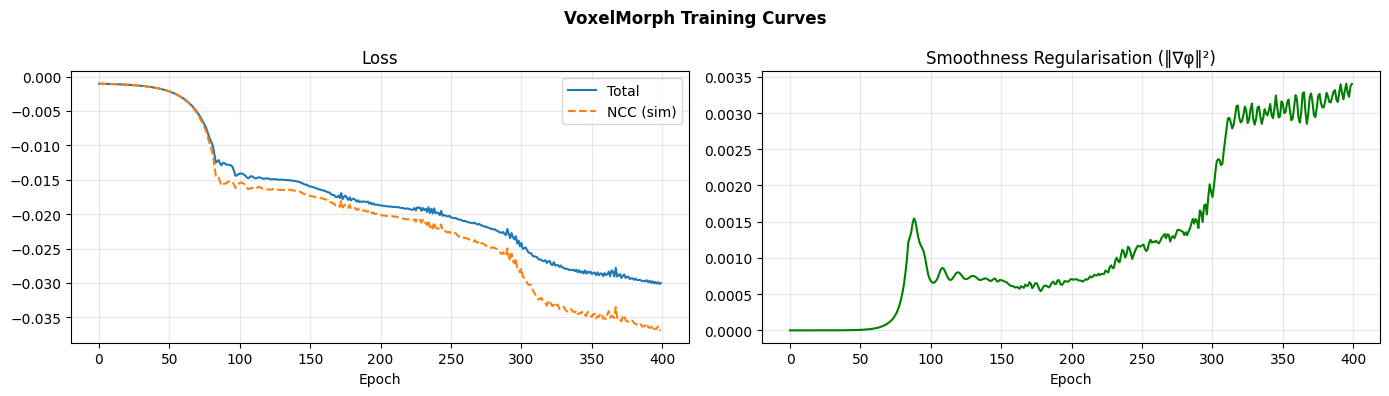

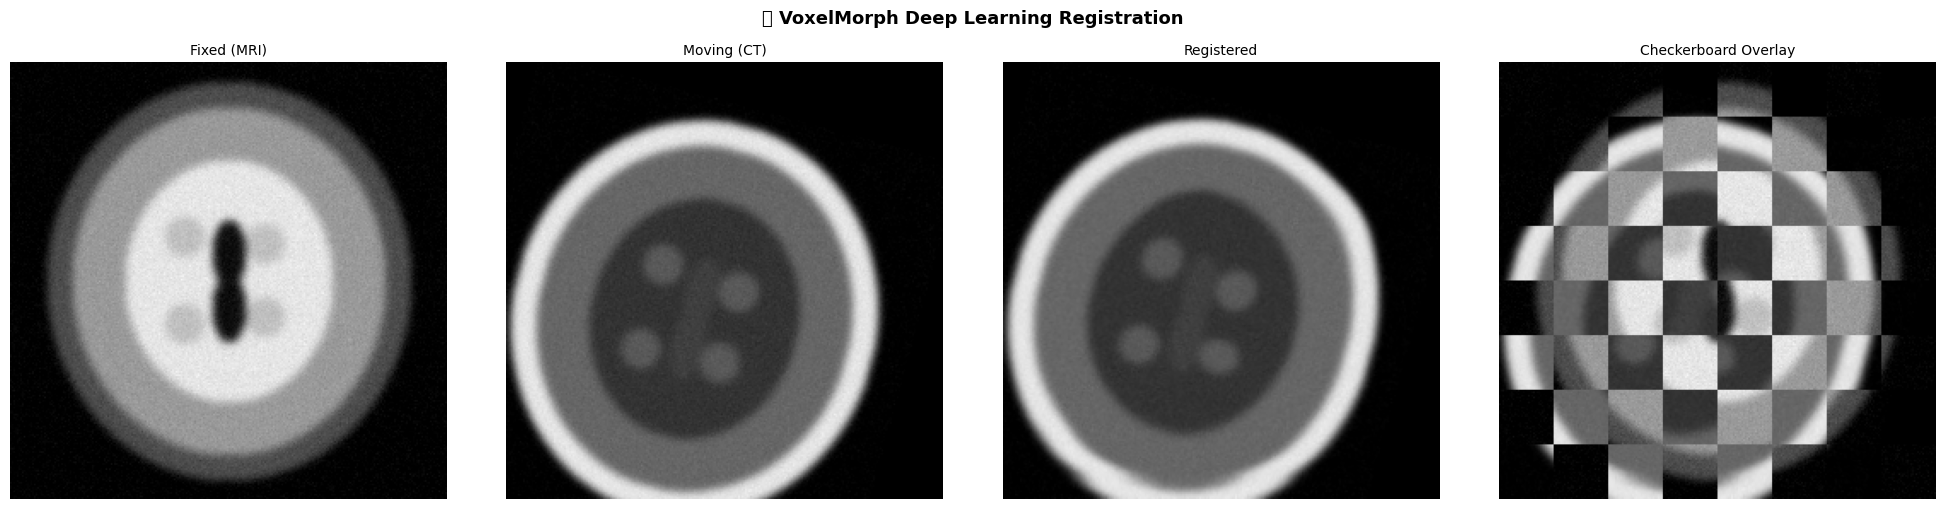

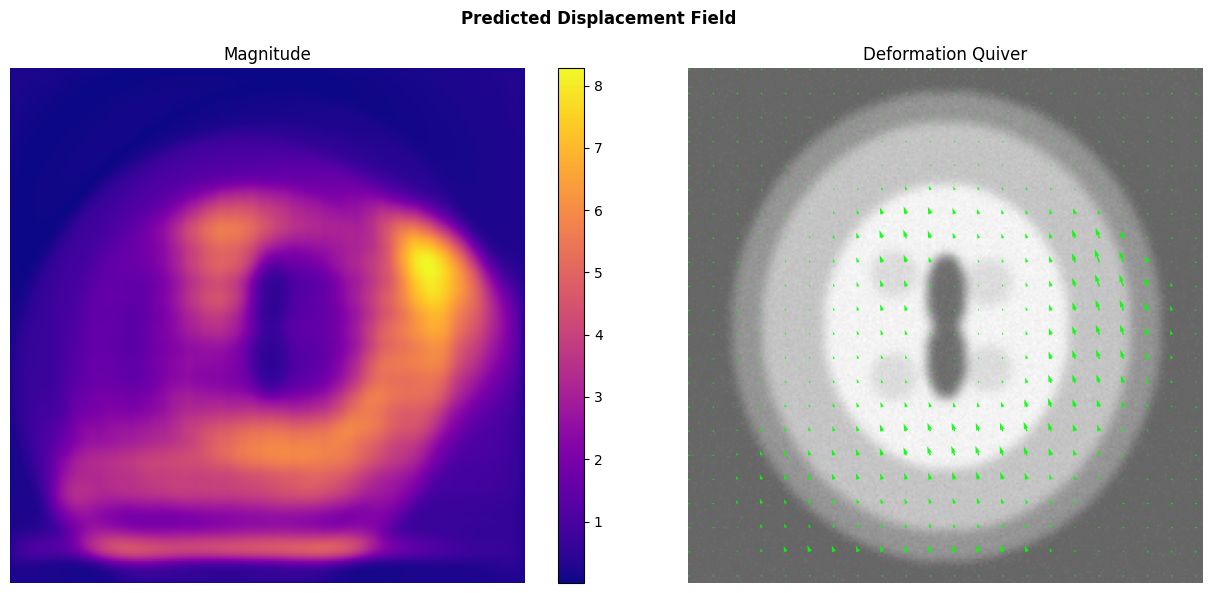

NMI (VoxelMorph DL): 1.0826


In [95]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,4))
fig.suptitle('VoxelMorph Training Curves',fontsize=12,fontweight='bold')
a1.plot(hist['total'],label='Total'); a1.plot(hist['sim'],'--',label='NCC (sim)')
a1.set_xlabel('Epoch'); a1.legend(); a1.grid(alpha=.3); a1.set_title('Loss')
a2.plot(hist['smooth'],color='green'); a2.set_xlabel('Epoch'); a2.grid(alpha=.3)
a2.set_title('Smoothness Regularisation (‖∇φ‖²)')
plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad():
    dl_reg_t, dl_flow = model(inp)
dl_result  = dl_reg_t.squeeze().cpu().numpy()
dl_flow_np = dl_flow.squeeze().permute(1,2,0).cpu().numpy()

show_registration(fixed_mri, moving_ct, dl_result,
                  suptitle='🤖 VoxelMorph Deep Learning Registration')

# Flow viz
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Predicted Displacement Field',fontsize=12,fontweight='bold')
mag=np.linalg.norm(dl_flow_np,axis=2)
im=a1.imshow(mag,cmap='plasma'); a1.set_title('Magnitude'); a1.axis('off'); plt.colorbar(im,ax=a1,fraction=.046)
a2.imshow(fixed_mri,cmap='gray',alpha=.6)
step=12; h,w=fixed_mri.shape; Y,X=np.mgrid[0:h:step,0:w:step]
a2.quiver(X,Y,dl_flow_np[::step,::step,0],dl_flow_np[::step,::step,1],
          color='lime',scale=300,width=.003,alpha=.9)
a2.set_title('Deformation Quiver'); a2.axis('off')
plt.tight_layout(); plt.show()

nmi_dl = normalized_mutual_information(fixed_mri, dl_result)
print(f"NMI (VoxelMorph DL): {nmi_dl:.4f}")

---
## Section 6 — Evaluation Metrics

| Metric | Best for | Higher better? |
|--------|----------|---------------|
| MAD (Mean Abs. Diff.) | Same modality | ↓ lower |
| NCC | Linear intensity relation | ↑ higher |
| NMI | Multimodal ✅ | ↑ higher |
| SSIM | Perceptual quality | ↑ higher |
| Jacobian det. | Deformation regularity | ~1, no negatives |

In [96]:
def metrics(fixed, result, name):
    mad  = np.abs(fixed-result).mean()
    ncc_ = np.corrcoef(fixed.ravel(), result.ravel())[0,1]
    nmi_ = normalized_mutual_information(fixed, result)
    ss   = ssim(fixed, result, data_range=1.0)
    return dict(Method=name, MAD=mad, NCC=ncc_, NMI=nmi_, SSIM=ss)

def jacobian_analysis(flow_np):
    dx_dy=np.gradient(flow_np[:,:,0],axis=0); dx_dx=np.gradient(flow_np[:,:,0],axis=1)
    dy_dy=np.gradient(flow_np[:,:,1],axis=0); dy_dx=np.gradient(flow_np[:,:,1],axis=1)
    jac=(1+dx_dx)*(1+dy_dy)-dx_dy*dy_dx
    return jac, (jac<0).mean()*100

results_table = [
    metrics(fixed_mri, moving_ct,     'Initial (none)'),
    metrics(fixed_mri, rigid_result,  'Rigid'),
    metrics(fixed_mri, affine_result, 'Affine'),
    metrics(fixed_mri, bspline_result,'B-Spline'),
    metrics(fixed_mri, dl_result,     'VoxelMorph (DL)'),
]

print("\n📊 Registration Quality Metrics")
print("─"*60)
print(f"{'Method':<22} {'MAD↓':>8} {'NCC↑':>8} {'NMI↑':>8} {'SSIM↑':>8}")
print("─"*60)
for m in results_table:
    print(f"{m['Method']:<22} {m['MAD']:>8.4f} {m['NCC']:>8.4f} {m['NMI']:>8.4f} {m['SSIM']:>8.4f}")
print("─"*60)

print("\n🔍 Jacobian Determinant (deformable methods):")
jac_dl, fp_dl = jacobian_analysis(dl_flow_np)
disp_np = sitk.GetArrayFromImage(disp_sitk)
jac_bs, fp_bs = jacobian_analysis(disp_np)
print(f"   VoxelMorph — mean={jac_dl.mean():.3f} std={jac_dl.std():.3f} folds={fp_dl:.2f}%")
print(f"   B-Spline   — mean={jac_bs.mean():.3f} std={jac_bs.std():.3f} folds={fp_bs:.2f}%")
print("   (0% folds = physically valid deformation ✅)")


📊 Registration Quality Metrics
────────────────────────────────────────────────────────────
Method                     MAD↓     NCC↑     NMI↑    SSIM↑
────────────────────────────────────────────────────────────
Initial (none)           0.2794   0.2903   1.0769   0.2682
Rigid                    0.2509   0.3675   1.1937   0.3093
Affine                   0.2503   0.3791   1.2562   0.2981
B-Spline                 0.2467   0.3875   1.2786   0.2947
VoxelMorph (DL)          0.2782   0.2865   1.0826   0.2862
────────────────────────────────────────────────────────────

🔍 Jacobian Determinant (deformable methods):
   VoxelMorph — mean=1.000 std=0.089 folds=0.00%
   B-Spline   — mean=1.028 std=0.089 folds=0.00%
   (0% folds = physically valid deformation ✅)


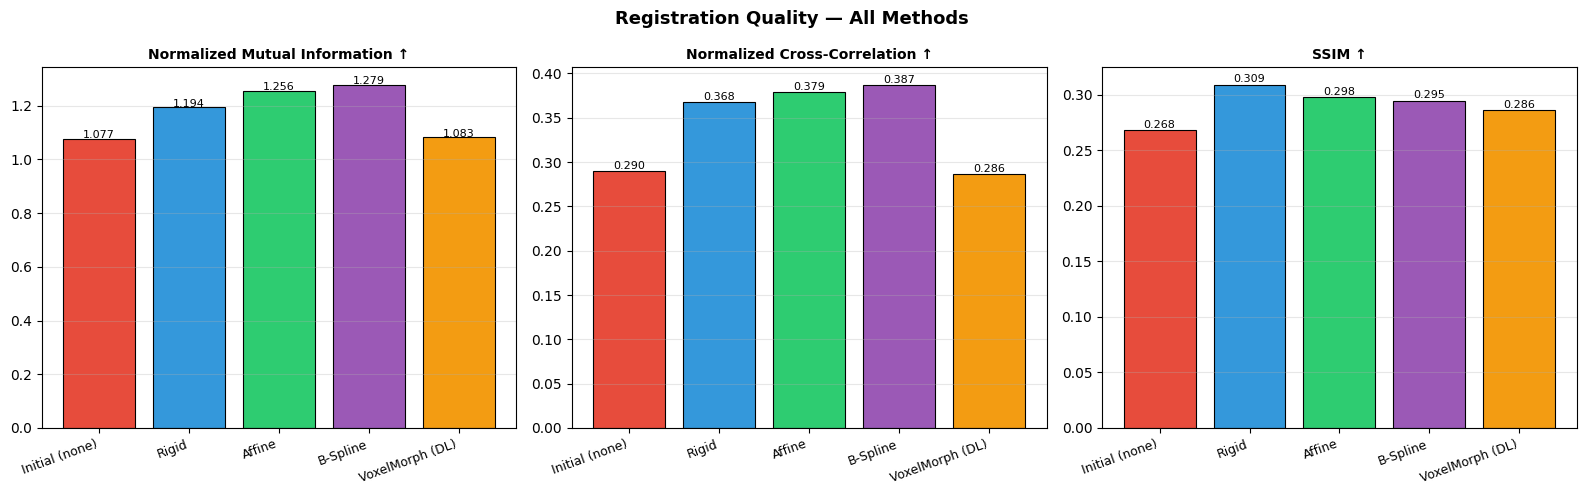

In [97]:
# Bar chart comparison
methods  = [m['Method'] for m in results_table]
colors   = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']
fig, axes= plt.subplots(1,3,figsize=(16,5))
fig.suptitle('Registration Quality — All Methods',fontsize=13,fontweight='bold')

for ax, key, label in zip(axes,['NMI','NCC','SSIM'],
        ['Normalized Mutual Information ↑','Normalized Cross-Correlation ↑','SSIM ↑']):
    vals=[m[key] for m in results_table]
    bars=ax.bar(methods,vals,color=colors,edgecolor='black',linewidth=.8)
    ax.set_title(label,fontsize=10,fontweight='bold')
    ax.set_xticklabels(methods,rotation=20,ha='right',fontsize=9)
    ax.grid(axis='y',alpha=.3)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.002,
                f'{v:.3f}',ha='center',fontsize=8)
plt.tight_layout(); plt.show()

---
## Section 7 — Full Comparison & 3D Extension

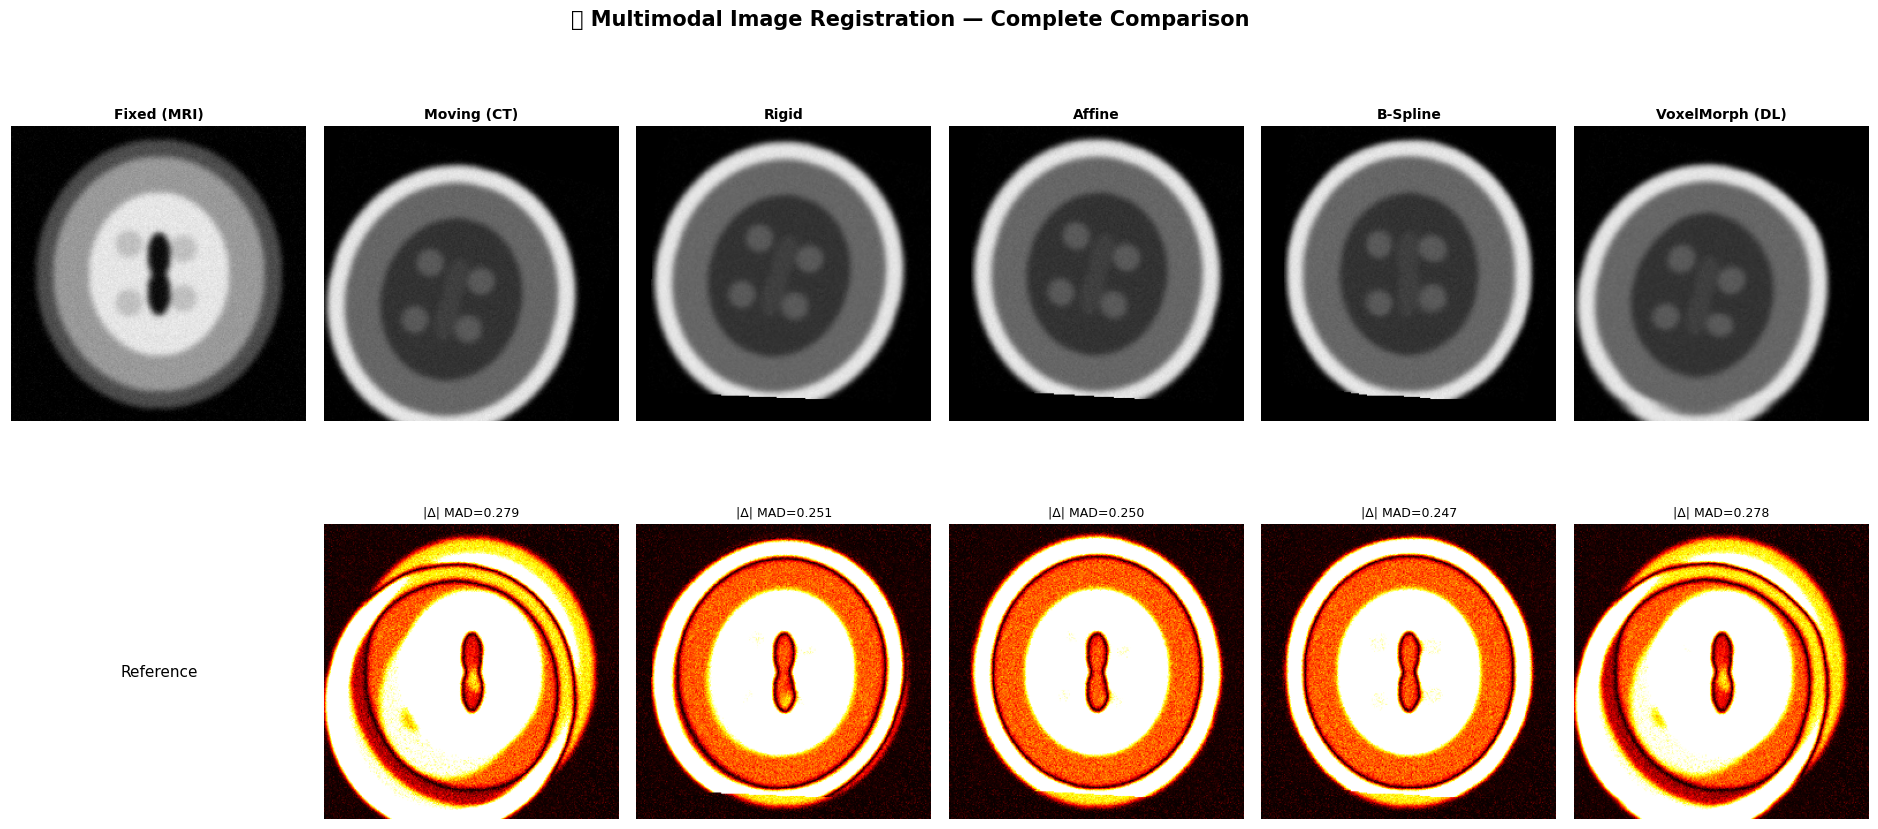

In [98]:
# Grand side-by-side comparison
all_imgs = [
    ('Fixed (MRI)',      fixed_mri),
    ('Moving (CT)',      moving_ct),
    ('Rigid',           rigid_result),
    ('Affine',          affine_result),
    ('B-Spline',        bspline_result),
    ('VoxelMorph (DL)', dl_result),
]
fig = plt.figure(figsize=(24,9))
gs  = gridspec.GridSpec(2,6,figure=fig,hspace=.35,wspace=.05)
fig.suptitle('🔬 Multimodal Image Registration — Complete Comparison',
             fontsize=15,fontweight='bold',y=1.01)
for i,(title,img) in enumerate(all_imgs):
    ax=fig.add_subplot(gs[0,i])
    ax.imshow(img,cmap='gray',vmin=0,vmax=1)
    ax.set_title(title,fontsize=10,fontweight='bold'); ax.axis('off')
for i,(title,img) in enumerate(all_imgs):
    ax=fig.add_subplot(gs[1,i])
    if i==0:
        ax.text(.5,.5,'Reference',ha='center',va='center',fontsize=11,transform=ax.transAxes)
        ax.axis('off')
    else:
        diff=np.abs(fixed_mri-img)
        ax.imshow(diff,cmap='hot',vmin=0,vmax=.4)
        ax.set_title(f'|Δ| MAD={diff.mean():.3f}',fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

✅ 3D rigid done in 0.3s


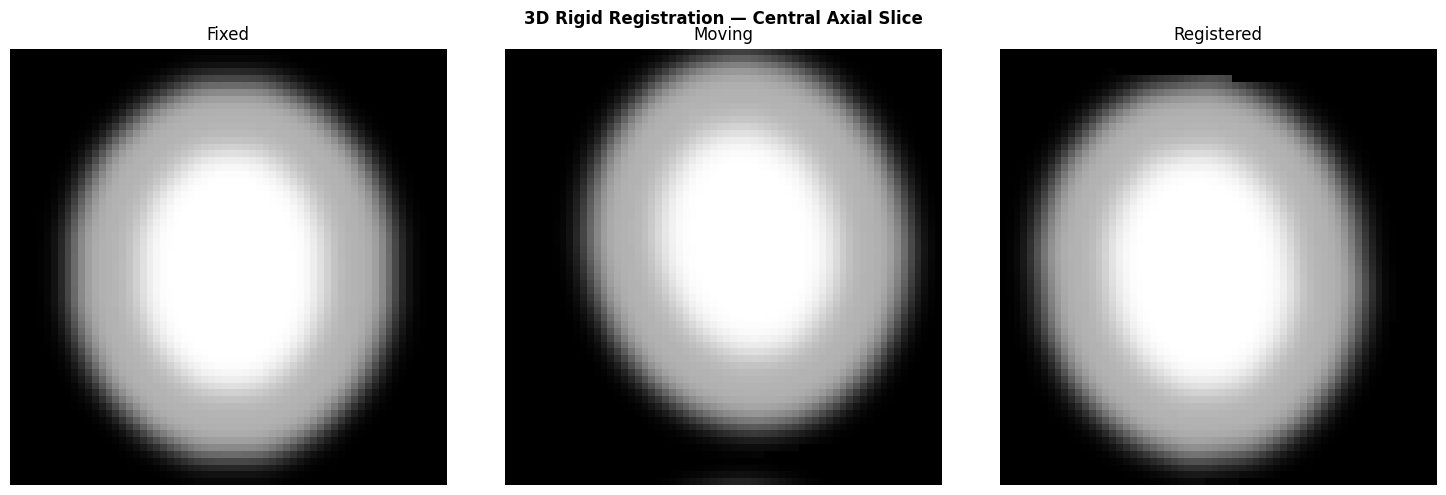

MAD before=0.0904  after=0.0449


In [99]:
# ── 3D Rigid Registration Sketch ─────────────────────────────────────────────
from scipy.ndimage import rotate as ndrotate

V = 64
vol = np.zeros((V,V,V),dtype=np.float32)
cz=cy=cx=V//2
z,y,x=np.ogrid[:V,:V,:V]
mask1=((z-cz)/25)**2+((y-cy)/28)**2+((x-cx)/24)**2<1
vol[mask1]=0.7
mask2=((z-cz)/15)**2+((y-cy)/18)**2+((x-cx)/14)**2<1
vol[mask2]=1.0
vol=gaussian_filter(vol,2.0)

vol_moved=ndrotate(vol,10,axes=(1,2),reshape=False)
vol_moved=np.roll(vol_moved,(5,-4,3),(0,1,2))

f3=sitk.GetImageFromArray(vol)
m3=sitk.GetImageFromArray(vol_moved)

r3=sitk.ImageRegistrationMethod()
r3.SetMetricAsMattesMutualInformation(32); r3.SetMetricSamplingStrategy(r3.RANDOM)
r3.SetMetricSamplingPercentage(.10); r3.SetInterpolator(sitk.sitkLinear)
r3.SetOptimizerAsGradientDescent(1.0,100,1e-6,10)
r3.SetOptimizerScalesFromPhysicalShift()
r3.SetShrinkFactorsPerLevel([2,1]); r3.SetSmoothingSigmasPerLevel([2,0])
r3.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
r3.SetInitialTransform(sitk.CenteredTransformInitializer(
    f3,m3,sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY),inPlace=False)
t0=time.time(); tf3=r3.Execute(f3,m3)
print(f"✅ 3D rigid done in {time.time()-t0:.1f}s")

rs=sitk.ResampleImageFilter(); rs.SetReferenceImage(f3)
rs.SetInterpolator(sitk.sitkLinear); rs.SetTransform(tf3)
reg3d=sitk.GetArrayFromImage(rs.Execute(m3))

slc=V//2
fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle('3D Rigid Registration — Central Axial Slice',fontsize=12,fontweight='bold')
for ax,img,title in zip(axes,[vol,vol_moved,reg3d],['Fixed','Moving','Registered']):
    ax.imshow(img[slc],cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print(f"MAD before={np.abs(vol-vol_moved).mean():.4f}  after={np.abs(vol-reg3d).mean():.4f}")

---
## Bonus — Real Data Registration with ANTsPy

ANTsPy wraps the **Advanced Normalization Tools (ANTs)** framework — the gold standard for neuroimaging registration used in FSL, FreeSurfer, and clinical pipelines. The flagship **SyN** (Symmetric Normalization) algorithm optimises a diffeomorphic (invertible, smooth) warp.

Fixed  shape=(256, 256)  spacing=(1.0, 1.0)
Moving shape=(256, 256)  spacing=(1.0, 1.0)

🔄 Running ANTs SyN (Rigid + Affine + SyN)...
✅ ANTs SyN complete in 1.6s


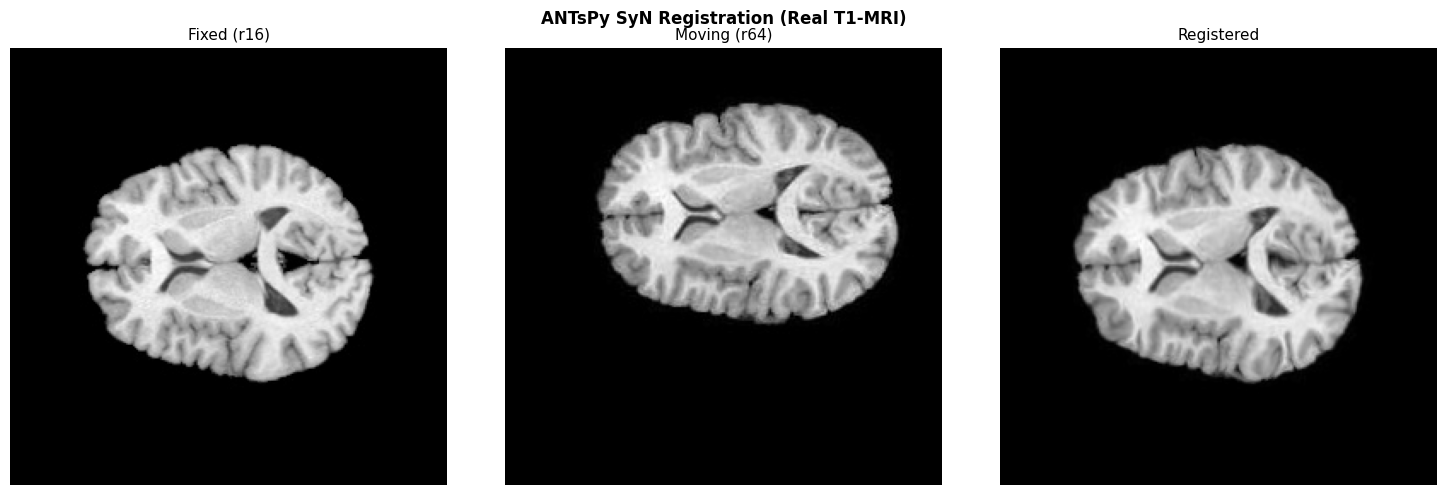


ANTs MSE after SyN: 191.2464
Transform files produced: ['warpedmovout', 'warpedfixout', 'fwdtransforms', 'invtransforms']


In [100]:
import ants

# ANTsPy ships built-in example brain slices
fi = ants.get_ants_data('r16')   # T1-MRI brain A
mi = ants.get_ants_data('r64')   # T1-MRI brain B

fixed_a  = ants.image_read(fi)
moving_a = ants.image_read(mi)
print(f"Fixed  shape={fixed_a.shape}  spacing={fixed_a.spacing}")
print(f"Moving shape={moving_a.shape}  spacing={moving_a.spacing}")

# ── SyN: Rigid → Affine → Diffeomorphic Deformable ───────────────────────────
print("\n🔄 Running ANTs SyN (Rigid + Affine + SyN)...")
t0=time.time()
result_a = ants.registration(
    fixed=fixed_a, moving=moving_a,
    type_of_transform='SyN',
    verbose=False)
print(f"✅ ANTs SyN complete in {time.time()-t0:.1f}s")

reg_a = result_a['warpedmovout']
fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle('ANTsPy SyN Registration (Real T1-MRI)',fontsize=12,fontweight='bold')
for ax,img,t in zip(axes,[fixed_a,moving_a,reg_a],['Fixed (r16)','Moving (r64)','Registered']):
    ax.imshow(img.numpy(),cmap='gray'); ax.set_title(t,fontsize=11); ax.axis('off')
plt.tight_layout(); plt.show()

sim=ants.image_similarity(fixed_a,reg_a,metric_type='MeanSquares')
print(f"\nANTs MSE after SyN: {sim:.4f}")
print("Transform files produced:", list(result_a.keys()))

In [101]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║       MULTIMODAL IMAGE REGISTRATION — SUMMARY & PRACTICAL GUIDE         ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  METHOD         | WHEN TO USE                   | DOF (3D)              ║
║  ─────────────  | ──────────────────────────── | ──────────────────    ║
║  Rigid          | Same anatomy, small motion    |  6                    ║
║  Affine         | Diff. scanners / resolution   | 12                    ║
║  B-Spline FFD   | Soft-tissue deformation       | ~1000s                ║
║  VoxelMorph DL  | Large datasets, speed needed  | millions (GPU)        ║
║                                                                          ║
║  SIMILARITY METRICS:                                                     ║
║  • MSE / SSD        → Same modality (MRI-MRI)                           ║
║  • NCC              → Linear intensity relationship                      ║
║  • Mattes MI / NMI  → Different modalities  ← preferred for CT+MRI     ║
║                                                                          ║
║  RECOMMENDED WORKFLOW:                                                   ║
║  1. Pre-process: skull-strip, normalise intensities                      ║
║  2. Multi-resolution pyramid always helps                                ║
║  3. Chain: Rigid → Affine → Deformable                                  ║
║  4. Check Jacobian det. < 0% for valid deformation                       ║
║  5. Evaluate: NMI + SSIM + visual checkerboard                          ║
║                                                                          ║
║  KEY LIBRARIES:                                                          ║
║  SimpleITK   github.com/SimpleITK/SimpleITK                             ║
║  ANTsPy      github.com/ANTsX/ANTsPy                                    ║
║  VoxelMorph  github.com/voxelmorph/voxelmorph                           ║
║  MONAI       monai.io  (end-to-end medical DL)                          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║       MULTIMODAL IMAGE REGISTRATION — SUMMARY & PRACTICAL GUIDE         ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  METHOD         | WHEN TO USE                   | DOF (3D)              ║
║  ─────────────  | ──────────────────────────── | ──────────────────    ║
║  Rigid          | Same anatomy, small motion    |  6                    ║
║  Affine         | Diff. scanners / resolution   | 12                    ║
║  B-Spline FFD   | Soft-tissue deformation       | ~1000s                ║
║  VoxelMorph DL  | Large datasets, speed needed  | millions (GPU)        ║
║                                                                          ║
║  SIMILARITY METRICS:                                                     ║
║  • MSE / SSD        → Same modality (MRI-MRI)                           ║
║  • NC

---
## 📚 Further Reading

| Resource | Description |
|----------|-------------|
| [SimpleITK Notebooks](https://github.com/InsightSoftwareConsortium/SimpleITK-Notebooks) | Official registration tutorial notebooks |
| Balakrishnan et al. 2019, IEEE TMI | Original VoxelMorph paper |
| [ANTs framework](http://stnava.github.io/ANTs) | Production neuroimaging registration |
| [MONAI](https://monai.io) | Medical deep learning framework with registration modules |
| [Learn2Reg challenge](https://learn2reg.grand-challenge.org) | Benchmark datasets & leaderboard |

---
*All code generates synthetic data in-place — no downloads required. Run on T4 GPU for best performance.*

---
## 🤔 Reflection Questions

Use these questions to consolidate your understanding of the key ideas covered in this tutorial.

---

### 1. Similarity Metrics & Modality Choice
Why is **Mutual Information (MI)** preferred over **Mean Squared Error (MSE)** when registering CT and MRI images? Under what circumstances might NCC still be a suitable alternative for multimodal registration?

---

### 2. Degrees of Freedom and Transform Selection
Rigid registration has 6 DOF in 3D, while affine registration has 12. Describe a real clinical scenario where the extra DOF of an affine transform would be *necessary*, and another where rigid registration would be *sufficient* (or even preferable). What are the risks of choosing a model with too many DOF?

---

### 3. The Role of Multi-Resolution Pyramids
Both the SimpleITK and deep learning pipelines use multi-resolution (coarse-to-fine) strategies. Explain *why* starting at a coarse scale helps avoid a common failure mode in iterative optimisation. What would likely happen if you ran optimisation directly at full resolution?

---

### 4. Warm-Starting and Method Chaining
The affine registration is warm-started from the rigid result, and the B-spline registration is warm-started from the affine result. What are the benefits of this cascaded initialisation strategy? Could you skip directly to B-spline registration from scratch? What problems might arise?

---

### 5. VoxelMorph Loss Function Design
The VoxelMorph loss combines an NCC similarity term and a gradient smoothness regulariser weighted by λ. 
- What happens to the displacement field if λ is set very close to 0? 
- What happens if λ is very large?  
- How would you systematically choose a good value for λ in practice?

---

### 6. Jacobian Determinant as a Quality Indicator
The Jacobian determinant of a displacement field is computed and checked for negative values. Explain what a negative Jacobian determinant means geometrically, why it is physically problematic in medical image registration, and how B-spline FFD and VoxelMorph differ in their ability to guarantee a valid (folding-free) deformation.

---

### 7. Evaluation Metric Trade-offs
The summary table reports MAD, NCC, NMI, and SSIM. 
- Which metric is most meaningful when the fixed and moving images come from *different* modalities, and why?  
- Why might a method score well on NMI but still produce a visually poor checkerboard overlay?

---

### 8. Deep Learning vs. Classical Registration
Compare VoxelMorph-style deep learning registration with the classical B-spline FFD approach across three dimensions: **training data requirements**, **inference speed**, and **interpretability of the estimated transform**. In which clinical or research contexts would each approach be more appropriate?

---

### 9. Extending to 3D
Section 7 sketched a 3D rigid registration on a synthetic volume. What additional challenges arise when scaling deformable registration to 3D volumes compared to 2D images? Consider memory, computation time, and quality assessment.

---

### 10. Real-World Pipeline Design
Suppose you are building a registration pipeline for a multi-site clinical trial that collects both T1-MRI and PET scans of the brain at multiple time-points across different scanner manufacturers. Based on everything in this tutorial, outline the registration steps you would recommend, justify your choice of similarity metric and transform model, and identify the biggest practical risks you would need to mitigate.
